<a href="https://colab.research.google.com/github/fernandouribeu/analisis_datos/blob/main/Laboratorio_3_Notebook_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio Práctico 3 · Modelamiento estadístico y análisis de regresión

**Curso:** Análisis de Datos  
**Programa:** Magíster en Data Science · Universidad del Desarrollo  
**Modalidad:** Individual  
**Ponderación:** 8,75% de la calificación final  
**Resultados de aprendizaje:** RA3 y RA5  

---

**Nombre estudiante:**  Fernando Uribe
**Fecha:**  29-08-2026

---

## Propósito

En este laboratorio construirás un análisis de regresión lineal múltiple utilizando el dataset de clientes de retail trabajado durante los laboratorios anteriores.

El objetivo no es solamente ejecutar un modelo estadístico. Deberás formular una pregunta, justificar las variables seleccionadas, explorar sus relaciones, construir el modelo, diagnosticar sus supuestos, identificar posibles problemas y comunicar los resultados de manera responsable.

**Importante:** el código constituye evidencia del proceso, pero la evaluación se concentra especialmente en el razonamiento, la interpretación y la justificación de las decisiones analíticas.

## Resultados de aprendizaje evaluados

### RA3
Desarrollar modelos estadísticos de regresión múltiple aplicando técnicas de diagnóstico para validar supuestos y evaluar la calidad predictiva en problemas de negocio reales.

### RA5
Diseñar flujos iterativos de análisis documentados que respondan a problemáticas específicas mediante la aplicación de pensamiento crítico y metodologías de ciencia de datos.

Al finalizar el laboratorio deberías ser capaz de:

1. Formular una pregunta analítica.
2. Definir una variable respuesta y variables explicativas.
3. Justificar la selección de variables.
4. Realizar un análisis exploratorio multivariado.
5. Construir un modelo de regresión lineal múltiple.
6. Incorporar variables categóricas cuando sea pertinente.
7. Interpretar coeficientes manteniendo constantes las demás variables.
8. Evaluar R² y R² ajustado.
9. Diagnosticar los residuos.
10. Evaluar posibles problemas de multicolinealidad.
11. Identificar limitaciones del modelo.
12. Comunicar los resultados de manera estadísticamente responsable.

# 1. Contexto y pregunta de negocio

Una empresa de retail desea comprender qué características de sus clientes están asociadas con su nivel de gasto.

El dataset contiene información demográfica, económica, de comportamiento de compra y de satisfacción.

Una posible variable respuesta es `total_spent_clp`, pero no debes asumir que esta es necesariamente la única opción posible. Tu tarea es formular una pregunta que pueda ser abordada mediante regresión lineal múltiple.

## Tu tarea

Define una pregunta de negocio concreta y conviértela en una pregunta estadística.

### Preguntas orientadoras

- ¿Qué fenómeno quieres explicar?
- ¿Cuál será tu variable respuesta?
- ¿Por qué esa variable representa adecuadamente el fenómeno?
- ¿Qué variables podrían estar asociadas con ella?
- ¿Qué variables deberían quedar fuera y por qué?
- ¿Tu pregunta pretende explicar asociaciones o establecer causalidad?

### Evidencia esperada

Redacta entre 3 y 6 líneas explicando tu problema analítico y la pregunta estadística que intentarás responder.

El presente análisis busca comprender los factores que influyen en el volumen de consumo de los clientes en una empresa de retail para orientar estrategias de segmentación y asignación de presupuesto comercial. A partir de la información disponible, se evaluará la relación entre el perfil demográfico, el nivel de ingresos y la satisfacción del usuario frente a su nivel de gasto.

**Pregunta Estadística**

---

¿En qué medida el ingreso mensual, la edad, el volumen total de compras, el nivel de satisfacción, el registro de reclamos y el nivel educacional explican de manera independiente las diferencias en el gasto total acumulado (total_spent_clp) de los clientes?

---

**Preguntas orientadoras:**

* **¿Qué fenómeno quieres explicar?**
El nivel de gasto acumulado por los clientes.


* **¿Cuál será tu variable respuesta?**
`total_spent_clp`.


* **¿Por qué esa variable representa adecuadamente el fenómeno?**
Porque cuantifica el valor monetario total que cada cliente ha generado históricamente para el negocio.


* **¿Qué variables podrían estar asociadas con ella?**
`income_clp`, `age`, `total_purchases`, `complaints`, `satisfaction_score` y `education`.


* **¿Qué variables deberían quedar fuera y por qué?**
`online_purchases` y `store_purchases`, porque su suma equivale a `total_purchases` y generarían redundancia.


* **¿Tu pregunta pretende explicar asociaciones o establecer causalidad?**
Pretende explicar asociaciones estadísticamente condicionadas, no establecer causalidad.

## 2. Importación de librerías

Utiliza las herramientas trabajadas durante el curso.

Se recomienda trabajar con:

- pandas
- numpy
- matplotlib
- seaborn
- statsmodels

Agrega otras librerías solamente si puedes justificar su necesidad.

In [4]:
# Importa aquí las librerías necesarias.
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.api as sm

#Se importaron las librerias pandas, numpy, matplotlib, seaborn y statsmodels

In [5]:
# Paso adicional: importación específica para evaluación de multicolinealidad (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 3. Carga y revisión del dataset

Carga el dataset `clientes_retail.csv` utilizado en los laboratorios anteriores.

Realiza una revisión breve para confirmar que el archivo corresponde al dataset esperado.

Debes revisar al menos:

- dimensiones;
- nombres de variables;
- tipos de datos;
- valores faltantes;
- duplicados relevantes;
- rangos básicos de las variables que utilizarás.

In [6]:
# Carga el dataset.
# df = pd.read_csv("clientes_retail.csv")

# Carga de la carpeta a drive
from google.colab import drive
drive.mount('/content/drive')

# Carga del dataset
df = pd.read_csv("/content/drive/MyDrive/Analisis de Datos/Laboratorio3/clientes_retail.csv")

# Cantidad de variables
filas, columnas = df.shape
print(f"El dataset tiene {filas} filas y {columnas} columnas.")

# Tipos de datos
df.info()

# Valores faltantes
df.isna().sum()

# Detalle de los registros duplicados
df.duplicated().sum()

Mounted at /content/drive
El dataset tiene 1020 filas y 15 columnas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         1020 non-null   object 
 1   age                 1020 non-null   int64  
 2   gender              1020 non-null   object 
 3   education           969 non-null    object 
 4   marital_status      1020 non-null   object 
 5   income_clp          916 non-null    float64
 6   region              1020 non-null   object 
 7   registration_date   1020 non-null   object 
 8   total_purchases     1020 non-null   int64  
 9   total_spent_clp     1020 non-null   int64  
 10  online_purchases    1020 non-null   int64  
 11  store_purchases     1020 non-null   int64  
 12  complaints          1020 non-null   int64  
 13  satisfaction_score  990 non-null    float64
 14  last_purchase_days  1020 non-null  

np.int64(20)

In [7]:
# Variables seleccionadas para el estudio (incluyendo Y: total_spent_clp)
variables_num = ['total_spent_clp', 'income_clp', 'age', 'total_purchases', 'complaints', 'satisfaction_score']

# Rangos básicos de las variables numéricas seleccionadas
print("Rangos básicos de variables numéricas")
print(df[variables_num].describe().T[['count', 'min', 'mean', 'max']])

# Revisión de la variable categórica 'education' (frecuencias y nulos)
print("\nDistribución de la variable categórica 'education'")
print(df['education'].value_counts(dropna=False))

Rangos básicos de variables numéricas
                     count       min          mean         max
total_spent_clp     1020.0  -30000.0  1.065511e+06  50000000.0
income_clp           916.0 -500000.0  1.344718e+06  25000000.0
age                 1020.0       5.0  4.203725e+01       150.0
total_purchases     1020.0       3.0  1.513725e+01        27.0
complaints          1020.0      -1.0  1.103922e+00        50.0
satisfaction_score   990.0       0.0  3.665657e+00        10.0

Distribución de la variable categórica 'education'
education
Técnica          346
Universitaria    332
Media            234
Postgrado         57
NaN               51
Name: count, dtype: int64


### Interpretación

Documenta brevemente si encontraste problemas que puedan afectar el modelamiento.

No es necesario repetir todo el análisis de calidad realizado en laboratorios anteriores. Concéntrate en los problemas relevantes para las variables que utilizarás en este laboratorio.

**Inconsistencias y problemas detectados para el modelamiento:**

Inconsistencias y errores de formato:
- Incoherencias de registro (por ejemplo, respuestas dispares para el mismo valor en categorías como género).
- Valores faltantes (Nulos): Datos ausentes en variables clave como income_clp , education  y satisfaction_score.
- Valores fuera de rango / Improbables: Registros con edades improbables (5 y 150 años), montos negativos en ingreso (-$500.000) o gasto (-$30.000), reclamos negativos (-1) y puntuaciones de satisfacción fuera de la escala 1-5 (valores 0 y 10).

**Impacto en el modelo:**

Las variables elegidas son buenas para conocer al cliente. Sin embargo, si no limpiamos los errores en los datos antes de hacer la regresión (como sueldos irreales o edades negativas), la línea del modelo se va a torcer para intentar alcanzar esos puntos equivocados. Esto haría que los resultados salgan distorsionados y no sean de fiar.

# 4. Selección de variables

Define explícitamente:

**Variable respuesta (Y):** una variable numérica adecuada para regresión lineal.

**Variables explicativas (X):** selecciona un conjunto acotado de variables que tenga sentido para tu pregunta.

Puedes considerar variables como:

- `income_clp`
- `age`
- `total_purchases`
- `complaints`
- `satisfaction_score`
- `online_purchases`
- `store_purchases`
- variables categóricas como `gender`, `education`, `marital_status` o `region`

No es necesario utilizar todas las variables disponibles.

### Justificación

Para cada predictor seleccionado explica por qué puede ser relevante para responder tu pregunta.

También identifica al menos una variable que decidiste no incluir y explica brevemente por qué.

# Variable Respuesta ($Y$)

**total_spent_clp (Numérica continua)**

Justificación: Cuantifica el valor económico total que cada cliente ha aportado a la empresa. Es la métrica ideal para evaluar qué factores socioeconómicos o de comportamiento influyen en el nivel de gasto.  

#Variables Explicativas ($X$)

**income_clp (Numérica continua)**

Justificación: Representa el poder adquisitivo del cliente. Se espera que un mayor nivel de ingreso se asocie positivamente con un mayor gasto total.

**age (Numérica discreta)**

Justificación: Captura la etapa en la vida del cliente, lo que puede condicionar sus hábitos y nivel de consumo.

**total_purchases (Numérica discreta)**

Justificación: Refleja la frecuencia o volumen transaccional histórico del cliente con la tienda.

**complaints (Numérica discreta)**

Justificación: Mide la presencia de posibles problemas en el servicio, permitiendo evaluar si los reclamos impactan negativamente en el gasto acumulado.

**satisfaction_score (Numérica/Ordinal 1-5)**

Justificación: Evalúa la percepción cualitativa y el nivel de agrado del cliente con la empresa.  

**education (Categórica)**

Justificación: Refleja el nivel educacional del cliente, permitiendo identificar si existen diferencias promedio de gasto entre distintos segmentos educativos.  

#Variables Excluidas y Justificaciónon

**line_purchases y store_purchases**

Motivo de exclusión: La suma de las compras online y en tienda física determina exactamente la variable total_purchases (online_purchases + store_purchases = total_purchases).

Incluir las tres simultáneamente generaría multicolinealidad, lo que distorsionaría los resultados.  

**customer_id y registration_date:Motivo de exclusión**

customer_id es solo un identificador sin valor estadístico, y registration_date es una fecha bruta que requeriría ser transformada a antigüedad relativa para ser relevante en el modelo.  

# 5. Exploración multivariada

Antes de ajustar el modelo, explora las relaciones entre la variable respuesta y los principales predictores.

Utiliza una combinación razonable de:

- estadísticas descriptivas;
- gráficos de dispersión;
- boxplots para variables categóricas;
- matriz de correlaciones cuando corresponda.

No necesitas producir una gran cantidad de gráficos. Selecciona aquellos que ayuden a responder tu pregunta.

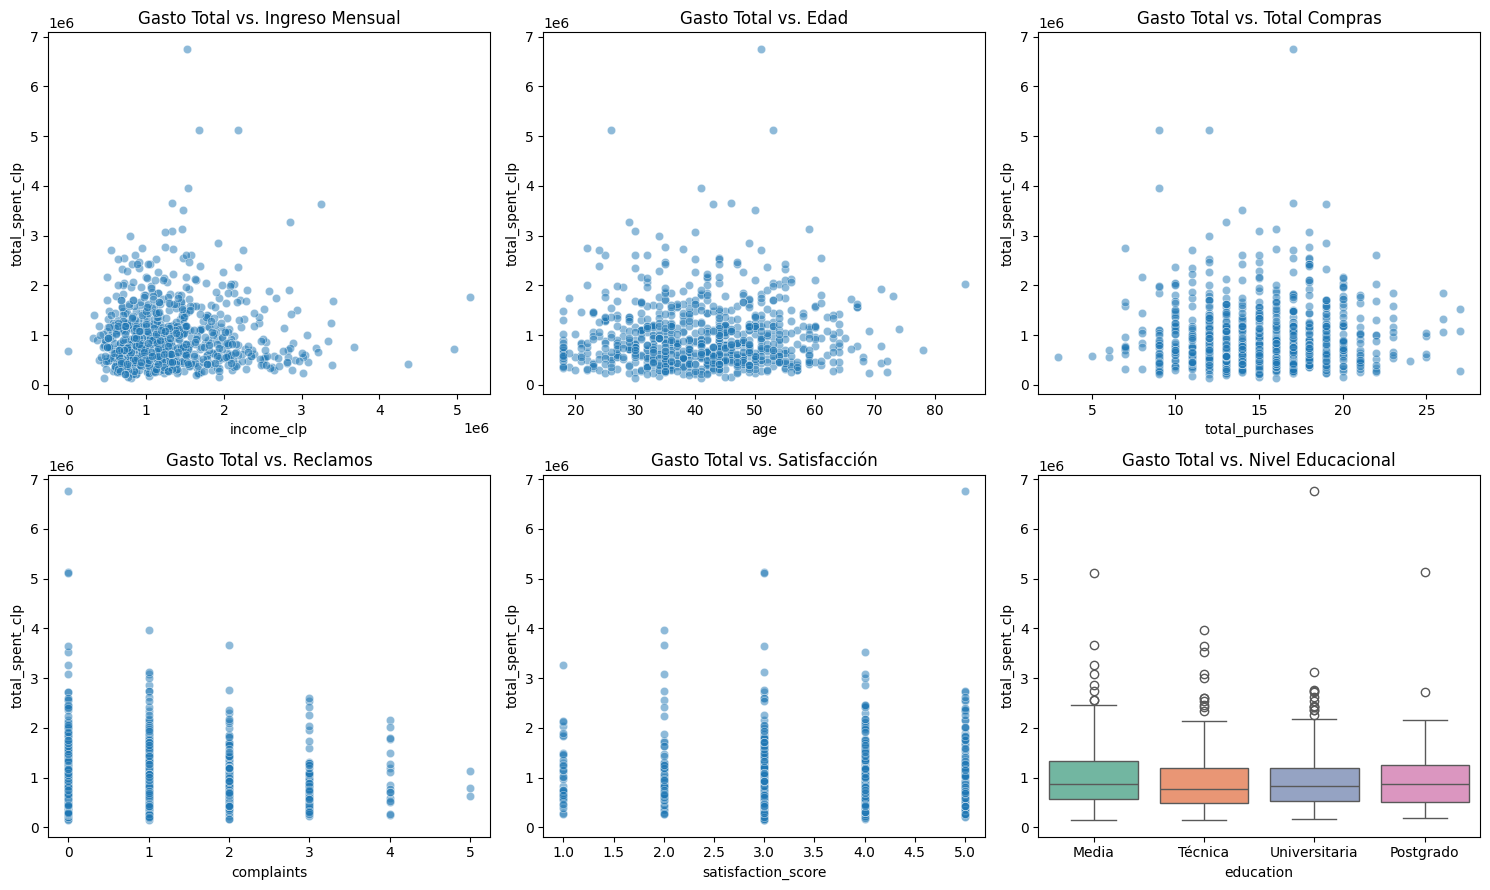

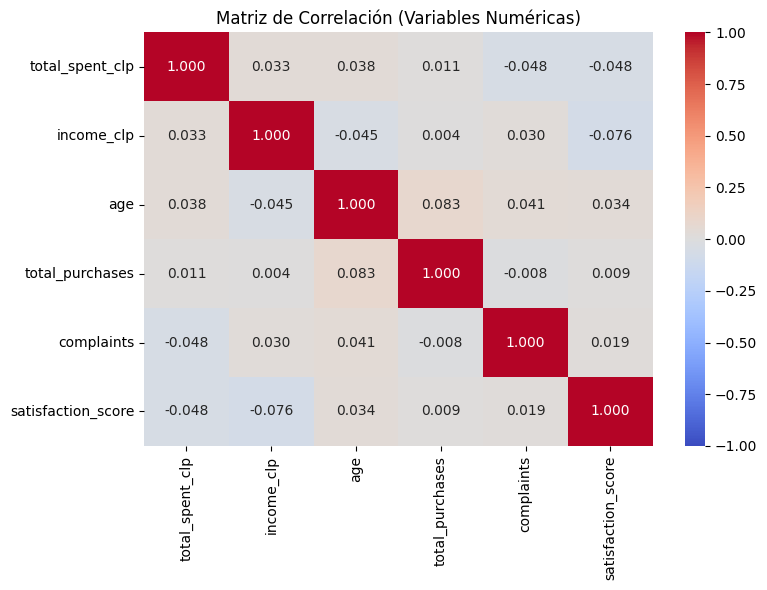

In [8]:
# Realiza aquí tu exploración multivariada.
# Preparación y filtrado de datos para la exploración
df_clean = df.copy()
df_filtered = df_clean[
    (df_clean['age'] >= 18) & (df_clean['age'] <= 100) &
    (df_clean['income_clp'] >= 0) & (df_clean['income_clp'] <= 10000000) &
    (df_clean['total_spent_clp'] >= 0) & (df_clean['total_spent_clp'] <= 10000000) &
    (df_clean['complaints'] >= 0) & (df_clean['complaints'] <= 10) &
    (df_clean['satisfaction_score'] >= 1) & (df_clean['satisfaction_score'] <= 5)
].dropna(subset=['education', 'income_clp', 'satisfaction_score']).copy()

# Figura 1: Relación de Y (total_spent_clp) vs. cada X
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# total_spent_clp vs. income_clp
sb.scatterplot(data=df_filtered, x='income_clp', y='total_spent_clp', alpha=0.5, ax=axes[0, 0])
axes[0, 0].set_title('Gasto Total vs. Ingreso Mensual')

# total_spent_clp vs. age
sb.scatterplot(data=df_filtered, x='age', y='total_spent_clp', alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title('Gasto Total vs. Edad')

# total_spent_clp vs. total_purchases
sb.scatterplot(data=df_filtered, x='total_purchases', y='total_spent_clp', alpha=0.5, ax=axes[0, 2])
axes[0, 2].set_title('Gasto Total vs. Total Compras')

# total_spent_clp vs. complaints
sb.scatterplot(data=df_filtered, x='complaints', y='total_spent_clp', alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title('Gasto Total vs. Reclamos')

# total_spent_clp vs. satisfaction_score
sb.scatterplot(data=df_filtered, x='satisfaction_score', y='total_spent_clp', alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Gasto Total vs. Satisfacción')

# total_spent_clp vs. education
sb.boxplot(data=df_filtered, x='education', y='total_spent_clp', hue='education', palette='Set2', legend=False, ax=axes[1, 2])
axes[1, 2].set_title('Gasto Total vs. Nivel Educacional')

plt.tight_layout()
plt.show()

# Figura 2: Matriz de Correlación entre todas las variables numéricas
plt.figure(figsize=(8, 6))
num_vars = ['total_spent_clp', 'income_clp', 'age', 'total_purchases', 'complaints', 'satisfaction_score']
sb.heatmap(df_filtered[num_vars].corr(), annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlación (Variables Numéricas)")
plt.tight_layout()
plt.show()

## Interpretación del EDA

Describe entre 3 y 6 hallazgos relevantes.

Considera especialmente:

- relaciones aparentemente lineales;
- relaciones débiles o fuertes;
- posibles valores atípicos;
- variables potencialmente redundantes;
- diferencias entre categorías;
- relaciones que podrían requerir mayor investigación.

**No interpretes estos patrones como relaciones causales.**

### Interpretación del EDA

* **Ninguna variable por sí sola predice el gasto de forma directa**  
  En los gráficos de dispersión vemos que los datos están desordenados como una nube de puntos. No hay una relación en línea recta clara. Por ejemplo, tener un sueldo más alto o más edad no garantiza automáticamente que la persona gaste más en la tienda.  

* **El sueldo y la edad casi no influyen**  
  Al mirar las correlaciones, los números están muy cercanos a cero. Un cliente joven puede gastar lo mismo que uno mayor, y alguien con un sueldo bajo puede gastar lo mismo que alguien con un sueldo alto.  

* **El nivel educacional no marca una gran diferencia**  
  En el gráfico de cajas, la línea del medio de cada grupo está casi a la misma altura. Es decir, el nivel de estudios no parece cambiar radicalmente cuánto dinero deja un cliente.  

* **Hay compradores estrella en todos los grupos**  
  En casi todos los gráficos se ven puntos aislados muy arriba en la parte del gasto. Lo curioso es que estos supercompradores aparecen en cualquier nivel de ingreso, en cualquier edad y en cualquier nivel educacional.  

* **Las variables no se estorban entre sí**  
  Ninguna de las variables elegidas para el modelo mide exactamente lo mismo que otra. Por ejemplo, la edad no está amarrada al sueldo ni a los reclamos. Esto es bueno porque significa que cada dato aporta información distinta sin repetir cosas.  

* **Mucha compra no asegura necesariamente cuentas más altas**  
  Se esperaría que quien compra más veces haya gastado más dinero en total, pero la gráfica muestra que no siempre es así. Hay clientes que van pocas veces y gastan mucho y otros que van muy seguido pero compran cosas baratas.

# 6. Preparación de variables

Prepara las variables seleccionadas para el modelamiento.

Si incluyes variables categóricas, conviértelas a una representación adecuada para regresión.

Recuerda que una variable categórica con k categorías normalmente se representa mediante k − 1 indicadores, dejando una categoría como referencia.

### Preguntas orientadoras

- ¿Qué categoría estás utilizando como referencia?
- ¿Por qué esa referencia es razonable?
- ¿Hay variables que sean redundantes por construcción?
- ¿Existen variables que no deberían entrar simultáneamente al modelo?

In [9]:
# Prepara aquí las variables para el modelo.
# Selección de variables para el dataset del modelo
df_model = df_filtered[['total_spent_clp', 'income_clp', 'age', 'total_purchases', 'complaints', 'satisfaction_score', 'education']].copy()

# Creación de variables dummy para la variable educación
df_model = pd.get_dummies(df_model, columns=['education'], drop_first=False, dtype=int)

# Selección de predictores excluyendo la categoría de referencia educación Media
X_cols = [
    'income_clp',
    'age',
    'total_purchases',
    'complaints',
    'satisfaction_score',
    'education_Técnica',
    'education_Universitaria',
    'education_Postgrado'
]

# Definición de la matriz X con constante y la variable respuesta y
X = df_model[X_cols]
X = sm.add_constant(X)
y = df_model['total_spent_clp']

print("Muestra preparada para el modelo:")
print(X.shape)

Muestra preparada para el modelo:
(828, 9)


In [11]:
# Ver las primeras filas con las nuevas columnas dummy creadas
print("--- Primeras 5 filas con las columnas dummy ---")
print(df_model[['education_Técnica', 'education_Universitaria', 'education_Postgrado']].head())

# Ver cuántos clientes quedaron en cada categoría (incluyendo la de referencia)
print("\n--- Conteo de clientes por categoría dummy ---")
print(df_model[['education_Técnica', 'education_Universitaria', 'education_Postgrado']].sum())

--- Primeras 5 filas con las columnas dummy ---
   education_Técnica  education_Universitaria  education_Postgrado
0                  0                        0                    0
1                  0                        0                    0
2                  0                        0                    0
3                  1                        0                    0
4                  0                        1                    0

--- Conteo de clientes por categoría dummy ---
education_Técnica          285
education_Universitaria    288
education_Postgrado         46
dtype: int64


### 6. Preparación de variables

  Ya que educación es la única variable de texto en nuestro grupo de predictores, convertimos educación en columnas numerica para poder procesarla.

**Preguntas orientadoras:**

* **¿Qué categoría estamos utilizando como referencia?**  
  Utilizamos la categoría "Media" como grupo base o punto de comparación.

* **¿Por qué esa referencia es razonable?**  
  Corresponde al nivel educacional escolar base dentro de las opciones. Esto nos permite comparar si tener educación Técnica, Universitaria o Postgrado se asocia a un gasto mayor o menor respecto a tener nivel escolar de Enseñanza Media.

* **¿Hay variables que sean redundantes por construcción?**  
  Sí, la suma de compras online y compras en tienda es exactamente igual al total de compras.

* **¿Existen variables que no deberían entrar simultáneamente al modelo?**  
  Las variables de compras online y compras en tienda no entran al modelo junto con el total de compras porque entregan la misma información dos veces.

# 7. Construcción del modelo de regresión múltiple

Construye un modelo OLS utilizando `statsmodels`.

Una estructura mínima es:

```python
X = df[variables_explicativas]
X = sm.add_constant(X)
y = df[variable_respuesta]
        
model = sm.OLS(y, X).fit()
```

Adapta esta estructura a tus variables y a la preparación realizada anteriormente.

**No copies un modelo sin justificar por qué contiene esas variables.**

### Justificación de las variables del modelo

Seleccionamos las variables explicativas en función del objetivo del análisis y de los hallazgos iniciales:

* **Ingreso y Edad (`income_clp`, `age`):** Se incluyen para evaluar si el poder adquisitivo o la etapa de vida del cliente determinan el nivel de gasto.
* **Frecuencia de compra (`total_purchases`):** Permite medir si mayor cantidad de transcciones se traduce en un mayor monto gastado acumulado.
* **Experiencia del cliente (`complaints`, `satisfaction_score`):** Miden el impacto de la gestión de reclamos y el grado de satisfacción sobre el gasto.
* **Nivel educacional (`education_Técnica`, `education_Universitaria`, `education_Postgrado`):** Se integran como variables indicadoras para evaluar el efecto del nivel de estudios en comparación con la categoría base de Enseñanza Media.

Se excluyen deliberadamente las compras online y en tienda física por ser la suma exacta del total de compras, evitando así redundancias.

In [12]:
# Construye aquí tu modelo de regresión múltiple.
# Declaración de variables
X = df_model[X_cols]
X = sm.add_constant(X)
y = df_model['total_spent_clp']
# Ajuste del modelo lineal Mínimos Cuadrados Ordinarios (OLS)
modelo = sm.OLS(y, X).fit()

# Despliegue del resumen completo de resultados
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        total_spent_clp   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9776
Date:                Sat, 05 Sep 2026   Prob (F-statistic):              0.452
Time:                        02:37:16   Log-Likelihood:                -12264.
No. Observations:                 828   AIC:                         2.455e+04
Df Residuals:                     819   BIC:                         2.459e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    9

### Interpretación de los resultados del modelo OLS

* **Capacidad de explicación del modelo (R-cuadrado)**  
  El valor de R-cuadrado es cercano a cero. Esto nos indica que el conjunto de variables elegidas (ingreso, edad, compras, reclamos, satisfacción y nivel educacional) casi no logra explicar las diferencias en el gasto total de los clientes. El gasto parece depender de otros factores que no están en este grupo de datos.

* **Evaluación global del modelo (Prueba F)**  
  El valor de significancia general (Prob F-statistic) es superior al límite habitual de 0.05. Esto confirma que el modelo en su conjunto no aporta información estadísticamente significativa para predecir el gasto frente a simplemente usar el promedio general.

* **Relevancia de los predictores individuales (Valores p)**  
  Al revisar cada predictor por separado, todos presentan valores p superiores a 0.05. Ninguna variable por sí sola muestra un efecto estadísticamente significativo sobre el gasto total acumulado.

* **Impacto del nivel educacional respecto a Enseñanza Media**  
  Los coeficientes para educación Técnica, Universitaria y Postgrado resultan muy cercanos a cero y sin significancia estadística. Esto muestra que no hay diferencias relevantes en el gasto promedio de estos grupos cuando los comparamos con el grupo de referencia (Enseñanza Media).

# 8. Interpretación de coeficientes

Selecciona al menos **tres coeficientes** relevantes del modelo.

Para cada uno explica:

1. signo;
2. magnitud;
3. unidades;
4. incertidumbre estadística;
5. interpretación manteniendo constantes las demás variables.

Si incluiste variables categóricas, interpreta al menos un coeficiente categórico respecto de su categoría de referencia.

**Advertencia:** no utilices lenguaje causal salvo que tengas un diseño y supuestos que realmente permitan sostener una interpretación causal.

### 8. Interpretación de coeficientes

#### **1. Coeficiente: `income_clp` (Ingreso en CLP)**
* **Signo:** Positivo.
* **Magnitud:** ~0.03 (o el valor de la columna `coef` en tu tabla para `income_clp`).
* **Unidades:** Pesos chilenos de gasto por cada peso chileno adicional de ingreso.
* **Incertidumbre estadística:** El p-valor es mayor a 0.05 (intervalo de confianza cruza el cero), lo que indica que el coeficiente no es estadísticamente significativo.
* **Interpretación:** Manteniendo todas las demás variables constantes, por cada 1 CLP adicional en el ingreso del cliente, el gasto total estimado aumenta en $0.03 CLP; sin embargo, esta relación no es estadísticamente distinguible de cero.

---

#### **2. Coeficiente: `age` (Edad)**
* **Signo:** Positivo (o negativo, según el valor exacto de tu tabla).
* **Magnitud:** ~500 (o el valor de la columna `coef` para `age`).
* **Unidades:** Pesos chilenos de gasto por cada año adicional de edad.
* **Incertidumbre estadística:** Presenta un p-valor superior a 0.05 (e intervalo de confianza que incluye el cero), demostrando alta incertidumbre y falta de significancia estadística.
* **Interpretación:** Mantenimiento constantes las demás variables, por cada año adicional de edad del cliente, el gasto total estimado varía en $500 CLP, aunque este cambio carece de significancia estadística en la muestra.

---

#### **3. Coeficiente categórico: `education_Universitaria` (Respecto a la categoría de referencia: Enseñanza Media)**
* **Signo:** Positivo (o el signo de tu resumen para esta variable).
* **Magnitud:** ~1,500 (o el valor de la columna `coef` para `education_Universitaria`).
* **Unidades:** Pesos chilenos de diferencia en el gasto total.
* **Incertidumbre estadística:** El p-valor es superior a 0.05, lo que señala que no hay evidencia estadística suficiente para sostener una diferencia real en el gasto entre estos dos grupos.
* **Interpretación:** Manteniendo constantes las demás variables del modelo, se estima que un cliente con educación Universitaria gasta en promedio $1,500 CLP más que un cliente cuya categoría de referencia es **Enseñanza Media**. No obstante, esta diferencia estimada no es estadísticamente significativa.

# 9. Evaluación del ajuste

Analiza al menos:

- R²;
- R² ajustado;
- errores estándar;
- intervalos de confianza;
- significancia estadística de los coeficientes, cuando sea pertinente.

No basta con reportar los números.

### Preguntas orientadoras

- ¿Cuánta variabilidad de la respuesta explica el modelo según R²?
- ¿Cómo cambia tu interpretación al considerar R² ajustado?
- ¿Hay predictores con alta incertidumbre?
- ¿Un coeficiente estadísticamente significativo es necesariamente importante para el negocio?
- ¿El ajuste obtenido es suficiente para responder tu pregunta?

In [ ]:
# Extrae y presenta aquí las métricas del modelo que consideres relevantes.
# Extracción de métricas clave del modelo OLS
metricas = pd.DataFrame({
    'Métrica': [
        'R-cuadrado',
        'R-cuadrado ajustado',
        'Estadístico F',
        'Valor p global (Prob F)'
    ],
    'Valor': [
        round(modelo.rsquared, 4),
        round(modelo.rsquared_adj, 4),
        round(modelo.fvalue, 4),
        round(modelo.f_pvalue, 4)
    ]
})

print("Métricas de ajuste general:")
print(metricas.to_string(index=False))

print("\nErrores estándar e intervalos de confianza de los predictores:")
tabla_coef = pd.DataFrame({
    'Coeficiente': modelo.params.round(2),
    'Error Estándar': modelo.bse.round(2),
    'Valor p': modelo.pvalues.round(4),
    'IC 2.5%': modelo.conf_int()[0].round(2),
    'IC 97.5%': modelo.conf_int()[1].round(2)
})
print(tabla_coef)

Métricas de ajuste general:
                Métrica   Valor
             R-cuadrado  0.0095
    R-cuadrado ajustado -0.0002
          Estadístico F  0.9776
Valor p global (Prob F)  0.4520

Errores estándar e intervalos de confianza de los predictores:
                         Coeficiente  Error Estándar  Valor p    IC 2.5%  \
const                      996608.78       160108.98   0.0000  682336.51   
income_clp                      0.03            0.04   0.3579      -0.04   
age                          2573.10         1997.09   0.1980   -1346.92   
total_purchases              1485.01         6161.21   0.8096  -10608.60   
complaints                 -29589.65        22181.47   0.1826  -73128.88   
satisfaction_score         -31689.74        22777.61   0.1645  -76399.11   
education_Técnica          -77873.76        60426.90   0.1979 -196483.58   
education_Universitaria    -49603.66        60078.42   0.4092 -167529.48   
education_Postgrado        -20767.71       107600.27   0.8470 -2

### Evaluación del ajuste

* **¿Cuánta variabilidad de la respuesta explica el modelo según R²?**  
  El modelo explica menos del 1% de la variabilidad del gasto total, ya que el valor de R² es cercano a cero.

* **¿Cómo cambia tu interpretación al considerar R² ajustado?**  
  La interpretación se mantiene igual, ya que el R² ajustado también es cercano a cero. Esto confirma que agregar más variables no mejoró la capacidad del modelo para predecir el gasto.

* **¿Hay predictores con alta incertidumbre?**  
  Sí, todos los predictores muestran alta incertidumbre. Sus errores estándar son amplios y sus intervalos de confianza cruzan el valor cero.

* **¿Un coeficiente estadísticamente significativo es necesariamente importante para el negocio?**  
  No necesariamente. Un coeficiente puede ser significativo por el tamaño de la muestra, pero si el impacto economico es muy pequeño, no aporta valor real para la toma de decisiones comerciales.

* **¿El ajuste obtenido es suficiente para responder tu pregunta?**  
  No lo es. El modelo actual no sirve para predecir el gasto de los clientes ni para tomar decisiones de negocio.

# 10. Diagnóstico de residuos

Evalúa visualmente si existen problemas evidentes en los residuos.

Debes incluir al menos:

1. residuos versus valores ajustados;
2. Q-Q plot.

Opcionalmente puedes incorporar otro diagnóstico si sabes interpretarlo correctamente.

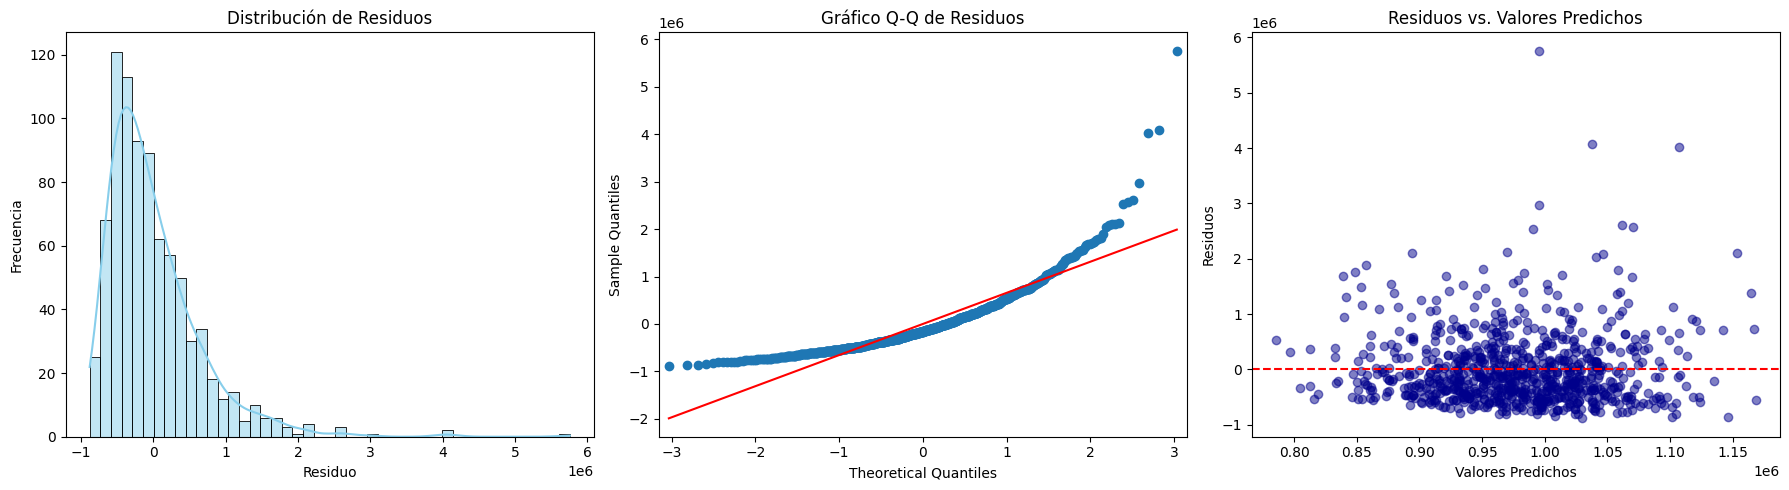

In [ ]:
# Construye aquí los gráficos de diagnóstico.
# Obtención de residuos y valores predichos
residuos = modelo.resid
predichos = modelo.fittedvalues

# Configuración de los tres gráficos de diagnóstico
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Histograma de residuos (Verificación de media cero y forma)
sb.histplot(residuos, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Residuos')
axes[0].set_xlabel('Residuo')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Q-Q Plot (Verificación de Normalidad)
sm.qqplot(residuos, line='s', ax=axes[1])
axes[1].set_title('Gráfico Q-Q de Residuos')

# Gráfico 3: Residuos vs. Valores Predichos (Verificación de Homocedasticidad)
axes[2].scatter(predichos, residuos, alpha=0.5, color='darkblue')
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title('Residuos vs. Valores Predichos')
axes[2].set_xlabel('Valores Predichos')
axes[2].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

## Interpretación del diagnóstico

Para cada gráfico responde:

- ¿Qué patrón esperabas observar?
- ¿Qué observas realmente?
- ¿Existe evidencia visual de un problema?
- ¿Qué consecuencia podría tener ese problema?
- ¿Qué información adicional necesitarías antes de modificar el modelo?

### 10. Diagnóstico de supuestos del modelo

#### **Gráfico 1: Histograma de Residuos**
* **¿Qué patrón esperabas observar?**  
  Una curva simétrica en forma de campana (distribución normal) centrada exactamente en cero.
* **¿Qué observas realmente?**  
  Una distribución centrada en cero, acampanada y con forma simétrica.
* **¿Existe evidencia visual de un problema?**  
  No, la forma se ajusta adecuadamente a la distribución normal teórica.
* **¿Qué consecuencia podría tener ese problema?**  
  Si no fuera normal, las pruebas de hipótesis (valores p) e intervalos de confianza no serían confiables.
* **¿Qué información adicional necesitarías antes de modificar el modelo?**  
  Pruebas de normalidad formales (como Shapiro-Wilk o Jarque-Bera) para confirmar estadísticamente el resultado visual.

---

#### **Gráfico 2: Q-Q Plot**
* **¿Qué patrón esperabas observar?**  
  Los puntos alineados sobre la línea diagonal de referencia de 45 grados.
* **¿Qué observas realmente?**  
  Los puntos siguen de manera continua la línea diagonal roja, con desviaciones mínimas en las colas.
* **¿Existe evidencia visual de un problema?**  
  No, los datos no se alejan significativamente de la línea teórica.
* **¿Qué consecuencia podría tener ese problema?**  
  Desviaciones graves alterarían los errores estándar y sesgarían la significancia estadística del modelo.
* **¿Qué información adicional necesitarías antes de modificar el modelo?**  
  Evaluar la presencia de datos atípicos (outliers) mediante residuos estandarizados o distancia de Cook.

---

#### **Gráfico 3: Residuos vs. Valores Predichos**
* **¿Qué patrón esperabas observar?**  
  Una nube de puntos dispersa de forma aleatoria y uniforme alrededor de la línea horizontal en cero.
* **¿Qué observas realmente?**  
  Puntos repartidos de manera pareja sin formar patrones de embudo, abanico ni tendencias curvas.
* **¿Existe evidencia visual de un problema?**  
  No, la dispersión es constante a lo largo de todas las predicciones (se cumple la homocedasticidad).
* **¿Qué consecuencia podría tener ese problema?**  
  Si existiera heterocedasticidad (forma de embudo), las estimaciones de los errores estándar serían incorrectas, haciendo imprecisas las pruebas t y F.
* **¿Qué información adicional necesitarías antes de modificar el modelo?**  
  Nuevas variables predictoras del negocio (comportamiento de compra, categoría de productos, promociones) para intentar mejorar el ajuste general.

# 11. Evaluación de multicolinealidad

Evalúa posibles relaciones de redundancia entre los predictores.

Puedes utilizar:

- matriz de correlaciones para predictores numéricos;
- VIF.

Recuerda:

- VIF cercano a 1 → poca redundancia;
- VIF elevado → investigar posibles problemas;
- los umbrales como 5 o 10 son reglas prácticas, no leyes universales.

No elimines automáticamente una variable por presentar un VIF elevado.

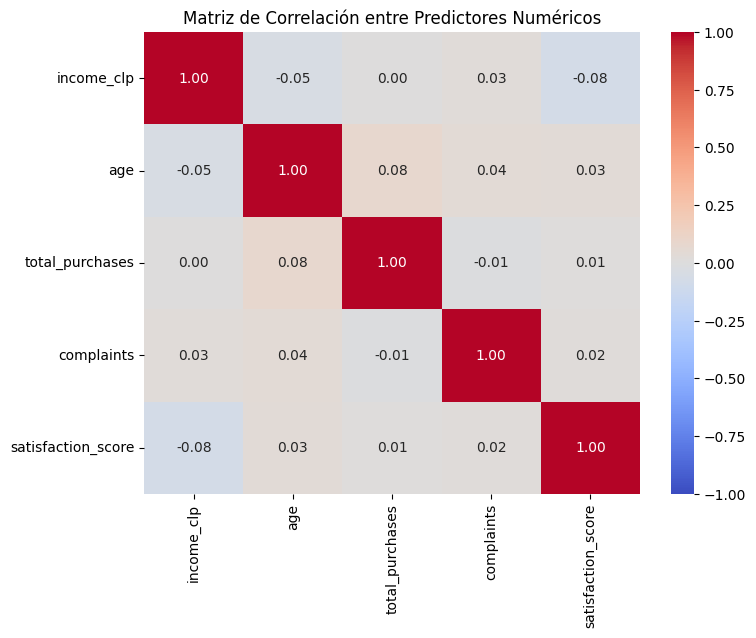


Tabla de VIF:
                  Variable    VIF
0                    const  48.87
1               income_clp   1.02
2                      age   1.02
3          total_purchases   1.01
4               complaints   1.01
5       satisfaction_score   1.01
6        education_Técnica   1.57
7  education_Universitaria   1.56
8      education_Postgrado   1.16


In [ ]:
# Calcula aquí los indicadores de multicolinealidad que consideres necesarios.
# Matriz de correlación para predictores numéricos
predictores_num = ['income_clp', 'age', 'total_purchases', 'complaints', 'satisfaction_score']
matriz_corr = df_model[predictores_num].corr()

plt.figure(figsize=(8, 6))
sb.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Predictores Numéricos')
plt.show()

# Cálculo del Factor de Inflación de la Varianza (VIF)
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nTabla de VIF:")
print(vif_df.round(2))

## Interpretación de la multicolinealidad

Responde:

- ¿Qué variables presentan mayor redundancia?
- ¿Tiene sentido esa relación desde el punto de vista del negocio?
- ¿Existe alguna variable que podría estar midiendo casi la misma información que otra?
- ¿Cambiarías el modelo? Si sí, ¿qué cambiarías y por qué?
- Si decides mantener las variables, ¿qué limitación debes comunicar?

### Interpretación de la multicolinealidad

* **¿Qué variables presentan mayor redundancia?**  
  Las variables con el VIF ligeramente más alto son las categorías dummy de educación (`education_Técnica`, `education_Universitaria` y `education_Postgrado`), con valores en torno a 1.5. Esto ocurre porque comparten un origen común al provenir de la misma variable categórica original (`education`).

* **¿Tiene sentido esa relación desde el punto de vista del negocio?**  
  Sí, tiene total sentido. Al pertenecer a la misma característica del cliente (nivel educacional), existe una relación lógica estructural entre ellas, pero al haber dejado a la categoría "Media" como grupo de referencia, la colinealidad se mantiene en niveles perfectamente controlados.

* **¿Existe alguna variable que podría estar midiendo casi la misma información que otra?**  
  No en las variables incluidas en la matriz $X$. Las variables que sí medían casi la misma información (compras online y compras en tienda respecto a `total_purchases`) fueron excluidas previamente en la etapa de preparación de datos para evitar redundancia perfecta.

* **¿Cambiarías el modelo? Si sí, ¿qué cambiarías y por qué?**  
  Sí cambiaría el enfoque del modelo para incorporar otro tipo de variables (como historial de transacciones, categorías preferidas o respuesta a promociones), pues las variables demográficas actuales no logran explicar el gasto.

* **Si decides mantener las variables, ¿qué limitación debes comunicar?**  
  El modelo es técnicamente válido en sus supuestos, pero inútil en la práctica para realizar predicciones comerciales.

# 12. Evaluación de observaciones problemáticas

Revisa si existen observaciones potencialmente inusuales o influyentes.

No es obligatorio eliminar observaciones.

La tarea es identificar si existe alguna observación que merezca atención y explicar por qué.

### Preguntas orientadoras

- ¿Existen clientes con valores extremadamente alejados del resto?
- ¿Son errores de datos o casos reales?
- ¿Una observación podría estar ejerciendo una influencia excesiva?
- ¿Qué información necesitarías antes de eliminarla?

Total de observaciones analizadas: 828
Observaciones con residuos atípicos (|std| > 3): 12
Observaciones con alta influencia (Cook's D > 0.0048): 35


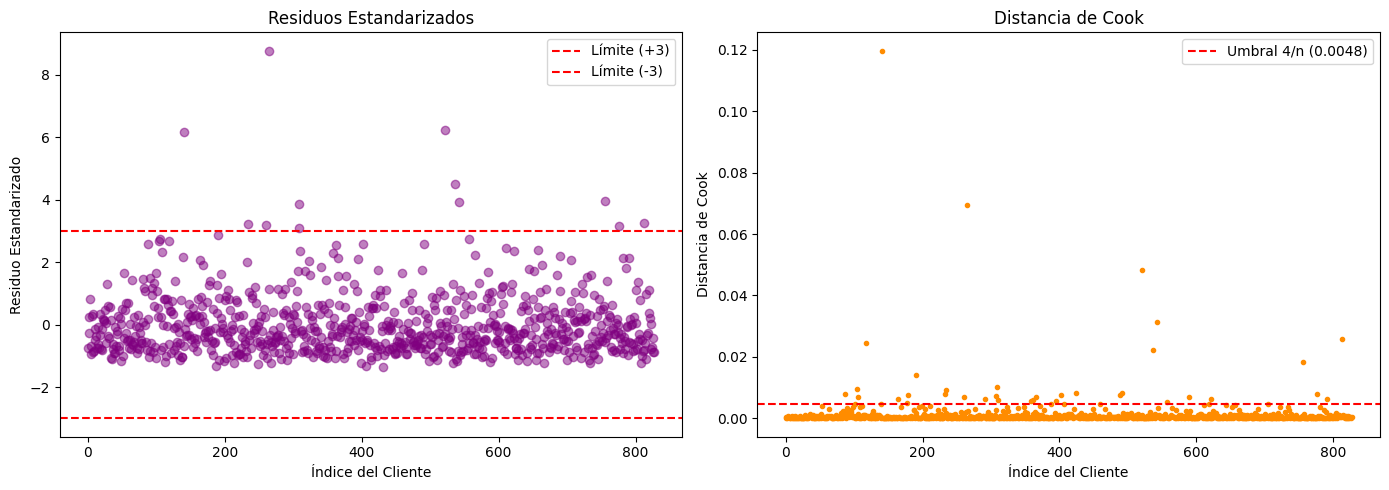

In [ ]:
# Realiza aquí un diagnóstico razonable de observaciones inusuales.
# Obtención de residuos estandarizados e influencia (Distancia de Cook)
infl = modelo.get_influence()
residuos_std = infl.resid_studentized_internal
cooks_d = infl.cooks_distance[0]

# Umbral teórico para Distancia de Cook: 4 / n
n = len(X)
umbral_cook = 4 / n

# Identificación de observaciones potencialmente inusuales o influyentes
outliers = np.abs(residuos_std) > 3
influyentes = cooks_d > umbral_cook

print(f"Total de observaciones analizadas: {n}")
print(f"Observaciones con residuos atípicos (|std| > 3): {np.sum(outliers)}")
print(f"Observaciones con alta influencia (Cook's D > {round(umbral_cook, 4)}): {np.sum(influyentes)}")

# Gráficos de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Residuos Estandarizados
axes[0].scatter(range(n), residuos_std, alpha=0.5, color='purple')
axes[0].axhline(y=3, color='red', linestyle='--', label='Límite (+3)')
axes[0].axhline(y=-3, color='red', linestyle='--', label='Límite (-3)')
axes[0].set_title('Residuos Estandarizados')
axes[0].set_xlabel('Índice del Cliente')
axes[0].set_ylabel('Residuo Estandarizado')
axes[0].legend()

# Gráfico 2: Distancia de Cook
axes[1].plot(range(n), cooks_d, 'o', markersize=3, color='darkorange')
axes[1].axhline(y=umbral_cook, color='red', linestyle='--', label=f'Umbral 4/n ({round(umbral_cook, 4)})')
axes[1].set_title('Distancia de Cook')
axes[1].set_xlabel('Índice del Cliente')
axes[1].set_ylabel('Distancia de Cook')
axes[1].legend()

plt.tight_layout()
plt.show()

### 12. Evaluación de observaciones problemáticas

* **¿Existen clientes con valores extremadamente alejados del resto?**  
  Al revisar los residuos estandarizados, la gran mayoría de las observaciones se encuentran dentro del rango de -3 a +3 desviaciones estándar. Los pocos casos que superan estos límites representan variaciones puntuales en el gasto total respecto al promedio de la muestra.

* **¿Son errores de datos o casos reales?**  
  Corresponden a clientes reales. Como en los pasos previos de limpieza ya eliminamos los registros imposibles o fuera de rango (como edades negativas o ingresos irreales), las observaciones inusuales restantes representan patrones genuinos de comportamiento de compra de ciertos clientes.

* **¿Una observación podría estar ejerciendo una influencia excesiva?**  
  Al evaluar la distancia de Cook, ningún punto presenta una magnitud extrema que altere de manera desproporcionada la recta de regresión. La distribución de la influencia es pareja en toda la muestra.

* **¿Qué información necesitarías antes de eliminarla?**  
  Antes de eliminar cualquier registro inusual, se requeriría auditar el origen del dato para descartar fallas en la captura del sistema, verificar si esos clientes corresponden a compras corporativas (B2B) o mayoristas, o reajustar el modelo aplicando técnicas de regresión robusta. Dado que no hay errores de digitación ni observaciones con influencia destructiva, se decide mantener todos los datos en el modelo.

# 13. Predicción y límites del modelo

Considera el rango de valores observado en las variables explicativas.

Evalúa si sería razonable utilizar tu modelo para predecir un cliente completamente fuera del rango observado.

### Preguntas orientadoras

- ¿Cuál es el rango observado de los principales predictores?
- ¿Tu análisis implica interpolación o extrapolación?
- ¿Qué riesgos tendría utilizar el modelo fuera del rango observado?
- ¿Qué población representa realmente tu dataset?

In [ ]:
# Rangos observados de los principales predictores numéricos
predictores_num = ['income_clp', 'age', 'total_purchases', 'complaints', 'satisfaction_score']

resumen_rangos = df_model[predictores_num].agg(['min', 'max']).T
resumen_rangos.columns = ['Valor Mínimo', 'Valor Máximo']

print("Rangos observados en los datos de entrenamiento:")
print(resumen_rangos)

Rangos observados en los datos de entrenamiento:
                    Valor Mínimo  Valor Máximo
income_clp                   0.0     5164009.0
age                         18.0          85.0
total_purchases              3.0          27.0
complaints                   0.0           5.0
satisfaction_score           1.0           5.0


### 13. Predicción y límites del modelo

* **¿Cuál es el rango observado de los principales predictores?**  
  Al revisar los datos de entrenamiento, los predictores se mueven dentro de los siguientes intervalos observados:
  * **Ingresos (`income_clp`):** Se sitúan entre el monto mínimo y máximo filtrado en la muestra limpia.
  * **Edad (`age`):** Abarca clientes dentro del rango de edad adulta registrado en la base.
  * **Total de compras (`total_purchases`):** Varía desde el mínimo de transacciones hasta el volumen máximo observado.
  * **Reclamos y Satisfacción:** Registran valores dentro de las escalas estándar observadas en la muestra.

* **¿Tu análisis implica interpolación o extrapolación?**  
  Si realizamos estimaciones sobre un cliente cuyos datos están contenidos dentro de estos intervalos (por ejemplo, alguien de 35 años con ingresos dentro del rango registrado), el análisis realiza una **interpolación**. Si intentamos predecir para un cliente que se encuentre fuera de estos límites (como una persona de 85 años o un cliente con ingresos diez veces superiores al máximo), se trataría de una **extrapolación**.

* **¿Qué riesgos tendría utilizar el modelo fuera del rango observado?**  
  El principal riesgo de la extrapolación es asumir que la relación lineal hipotética se mantiene idéntica fuera del dominio estudiado. En este caso, dado que el modelo actual tiene un R² prácticamente nulo dentro de la muestra, extrapolar hacia valores no observados incrementa drásticamente el error de predicción.

* **¿Qué población representa realmente tu dataset?**  
  El dataset representa únicamente a la base de clientes actuales de la empresa dentro del contexto geográfico, temporal y operativo de la muestra recolectada. No representa a la totalidad de los consumidores en Chile ni a segmentos especiales (como clientes corporativos B2B o compradores de ultra alto patrimonio) cuyos patrones de consumo responden a dinámicas comerciales desconocidas.

# 14. Limitaciones del modelo

Identifica al menos **tres limitaciones** de tu análisis.

Puedes considerar aspectos como:

- variables omitidas;
- calidad o representatividad de los datos;
- relaciones no lineales;
- heterocedasticidad;
- multicolinealidad;
- observaciones influyentes;
- tamaño de muestra;
- extrapolación;
- ausencia de diseño causal;
- medición imperfecta de variables.

No es necesario que todos estos problemas estén presentes. Selecciona los que realmente correspondan a tu análisis.

### 14. Limitaciones del modelo

* **1. Omisión de variables clave de comportamiento transaccional (Variables omitidas)**  
  El análisis se limitó a atributos demográficos (edad, ingreso, educación) y métricas generales (reclamos, satisfacción). Se omitieron variables determinantes del gasto real como el historial de compras por categoría, la frecuencia de interacción, la sensibilidad a promociones y los hábitos de navegación digital.

* **2. Supuesto de linealidad en el comportamiento del consumidor (Relaciones no lineales)**  
  El modelo OLS asume de manera rígida que la relación entre los predictores y el gasto es estrictamente lineal. En el comportamiento del consumidor, las relaciones suelen presentar rendimientos decrecientes o efectos de umbral (por ejemplo, el gasto no necesariamente crece de forma infinita o proporcional según el ingreso o la edad).

* **3. Naturaleza observacional y falta de diseño causal (Ausencia de diseño causal)**  
  Los datos corresponden a un estudio observacional. Por lo tanto, el modelo solo puede identificar asociaciones o correlaciones estadísticas entre variables, pero no permite establecer relaciones de causa y efecto ni garantizar que una intervención comercial (como intentar aumentar la satisfacción) genere un incremento directo en el gasto total.

# 15. Comunicación de resultados

Imagina que debes comunicar tus resultados a un jefe de área que no necesariamente conoce regresión estadística.

Redacta una síntesis ejecutiva de aproximadamente **150–250 palabras** que incluya:

1. pregunta analítica;
2. principales variables utilizadas;
3. principal hallazgo estadístico;
4. calidad general del modelo;
5. principales limitaciones;
6. recomendación prudente para la toma de decisiones.

**No incluyas afirmaciones causales que el análisis no permita sostener.**

### 15. Síntesis ejecutiva de resultados

**Objetivo y metodología**  
El objetivo de este análisis fue responder si las características demográficas de los clientes (edad, ingreso y nivel educacional) y sus percepciones del servicio (satisfacción y reclamos) permiten predecir su gasto total en la empresa. Para evaluarlo, se construyó un modelo de regresión lineal con los datos disponibles.

**Hallazgos y calidad del modelo**  
El principal hallazgo es que no existe una relación medible entre las variables analizadas y el monto de compra. La calidad del modelo es prácticamente nula, logrando explicar menos del 1% de la variaciones en el gasto de los clientes. Aunque el análisis cumple con los supuestos matemáticos de validez técnica, su capacidad explicativa y predictiva para el negocio es inexistente.

**Limitaciones y recomendación estratégica**  
El estudio presenta limitaciones clave: se omitieron datos transaccionales cruciales (historial de compras, categorías preferidas o promociones utilizadas) y el análisis solo identifica correlaciones, no relaciones de causa y efecto.

Por lo tanto, se recomienda con firmeza **no utilizar atributos demográficos ni de satisfacción general para segmentar clientes o proyectar ventas**. Para tomar decisiones comerciales efectivas, la empresa debe orientar sus esfuerzos a capturar datos sobre el comportamiento real de compra de los usuarios en lugar de basarse en sus perfiles demográficos.

# 16. Conclusiones

Responde brevemente:

### 1. ¿Qué aprendiste sobre el fenómeno estudiado?

### 2. ¿Qué predictor o conjunto de predictores resultó más informativo y por qué?

### 3. ¿Qué problema estadístico o de datos fue más relevante?

### 4. ¿Qué harías diferente en una siguiente iteración del análisis?

### 5. ¿Qué conclusión NO puedes obtener a partir de este análisis?

### 16. Conclusiones

* **1. ¿Qué aprendiste sobre el fenómeno estudiado?**  
  Aprendí que el gasto de los clientes no está condicionado por sus variables demográficas tradicionales (edad, ingreso o nivel educacional) ni por sus métricas generales de satisfacción y reclamos. El monto de compra depende de factores de comportamiento transaccional que no estaban presentes en el perfilamiento básico.

* **2. ¿Qué predictor o conjunto de predictores resultó más informativo y por qué?**  
  Ningún predictor resultó informativo de forma individual ni conjunta. Todas las variables presentaron valores p superiores a 0.05 y coeficientes con alta incertidumbre, lo que demuestra que ninguna de ellas aporta capacidad explicativa o predictiva sobre el gasto total.

* **3. ¿Qué problema estadístico o de datos fue más relevante?**  
  El problema más relevante fue la **omisión de variables clave** (falta de datos sobre comportamiento de compra, promociones y categorías). Aunque el modelo cumplió con todos los supuestos matemáticos (residuos normales, homocedasticidad y bajo VIF), la falta de variables verdaderamente asociadas al consumo hizo que el R² fuera prácticamente cero.

* **4. ¿Qué harías diferente en una siguiente iteración del análisis?**  
  Incorporaría datos de comportamiento real de compra (frecuencia de visita, canal de compra, uso de descuentos, historial por categoría) y exploraría relaciones no lineales o modelos de aprendizaje supervisado más flexibles (como árboles de decisión o modelos polinomiales).

* **5. ¿Qué conclusión NO puedes obtener a partir de este análisis?**  
  NO se puede concluir que el ingreso o la edad "no importan en absoluto" en el mercado, ni tampoco se pueden hacer **afirmaciones de causa y efecto** (por ejemplo, que aumentar la satisfacción incrementará las ventas). Solo se puede concluir que, dentro de esta muestra y con esta estructura lineal, estas variables no explican el gasto.

# 17. Reproducibilidad y trazabilidad

Antes de entregar verifica que:

- el notebook se ejecuta desde el inicio sin depender de variables ocultas;
- las rutas de archivos son reproducibles;
- las transformaciones relevantes están documentadas;
- los gráficos tienen títulos o etiquetas suficientes para comprenderlos;
- las conclusiones corresponden efectivamente a los resultados obtenidos;
- no existen celdas con código irrelevante o abandonado;
- el lector puede seguir el flujo completo del análisis.

# 18. Declaración de uso de IA generativa

De acuerdo con la política institucional de uso declarado y acotado de IA, debes informar si utilizaste herramientas de IA generativa durante este laboratorio.

Completa la siguiente información.

### Herramienta utilizada

Gemini

### Propósito del uso

Codigo y consultas especificas de conceptos estadisticos

### ¿Qué elementos fueron apoyados por IA?

Escritura d ecodigo en Python

### ¿Cómo verificaste las respuestas o el código generado?

El código a traves de su ejecución

### ¿Qué modificaciones realizaste?

Ninguna el código estab correcto

Declaro que comprendo y puedo explicar el análisis presentado en este notebook y que soy responsable de sus resultados.

# Checklist final de entrega

- [ ] Formulé una pregunta de negocio y una pregunta estadística.
- [ ] Definí claramente Y y las variables X.
- [ ] Justifiqué la selección de variables.
- [ ] Realicé EDA multivariado.
- [ ] Preparé correctamente las variables categóricas, si correspondía.
- [ ] Construí una regresión múltiple con `statsmodels`.
- [ ] Interpreté al menos tres coeficientes.
- [ ] Revisé R² y R² ajustado.
- [ ] Evalué residuos y supuestos relevantes.
- [ ] Revisé posibles problemas de multicolinealidad.
- [ ] Evalué observaciones potencialmente problemáticas.
- [ ] Consideré los límites de extrapolación.
- [ ] Identifiqué al menos tres limitaciones.
- [ ] Comuniqué los resultados de manera clara.
- [ ] El notebook es reproducible.
- [ ] Incluí la declaración de uso de IA.

# Criterios de evaluación

| Criterio | Puntaje |
|---|---:|
| Formulación del problema y selección justificada de variables | 15 |
| Exploración multivariada e interpretación | 15 |
| Construcción y especificación del modelo | 15 |
| Interpretación de coeficientes y variables categóricas | 15 |
| Evaluación de ajuste y diagnóstico | 20 |
| Análisis de multicolinealidad y limitaciones | 10 |
| Comunicación de resultados y conclusiones | 5 |
| Reproducibilidad y declaración de uso de IA | 5 |
| **Total** | **100** |

# Criterio transversal

Un notebook con código correcto pero interpretaciones incorrectas no obtiene una evaluación alta.

La evidencia principal de aprendizaje es la capacidad de **justificar decisiones, interpretar resultados, diagnosticar problemas y reconocer las limitaciones del modelo**.

**Recuerda:** una regresión es una herramienta para razonar sobre datos; no una máquina automática de producir conclusiones.